 # Part B – Dataset Understanding & Preparation

In [23]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# # Model selection and cross-validation tools
# from sklearn.model_selection import (
#     train_test_split, KFold, StratifiedKFold, LeaveOneOut, TimeSeriesSplit, 
#     cross_validate, GridSearchCV, cross_val_score
# )

from sklearn.model_selection import train_test_split

# Preprocessing & Core Regressors
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Matplotlib & Seaborn Styling configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Suppress minor warnings for clean notebook output
import warnings
warnings.filterwarnings('ignore')

print("All advanced machine learning dependencies successfully loaded!")


All advanced machine learning dependencies successfully loaded!


In [24]:
df = pd.read_csv("dataset.csv")

In [25]:
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [26]:
df.shape

(3800, 12)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


In [28]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

In [29]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


In [30]:
X = df.drop(columns=['house_price_inr'])

In [31]:
y = df['house_price_inr']

In [32]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

In [33]:
pip install sweetviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import sweetviz as sv

report = sv.analyze(df)

report.show_html()


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


<Axes: >

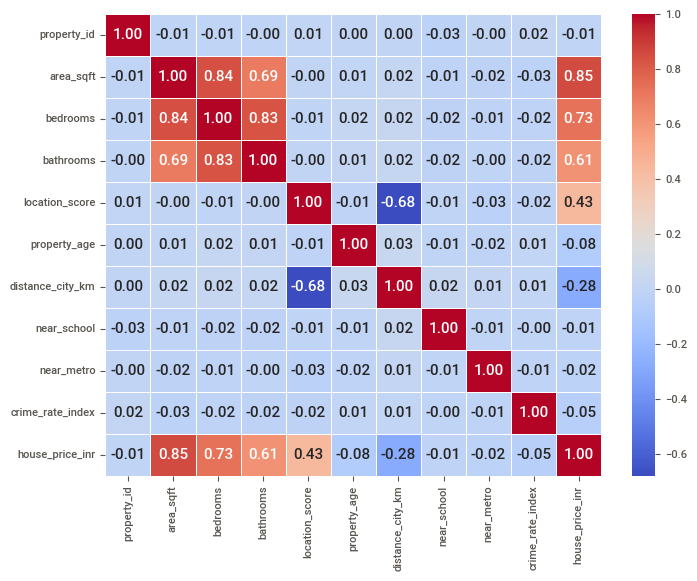

In [35]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, 
    annot=True,       # Display data values in each cell
    cmap='coolwarm',  # Color palette (blue for negative, red for positive correlations)
    fmt=".2f",        # Format of the annotations to 2 decimal places
    ax=ax, 
    linewidths=0.5    # Lines separating cells
)

In [36]:
df['sale_year'] = df['sale_date'].dt.year

In [37]:
df.drop(columns=['property_id', 'sale_date'], inplace=True)

In [38]:
X = df.drop(columns=['house_price_inr'])

y = df['house_price_inr']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3040, 10)
(760, 10)
(3040,)
(760,)


In [43]:
scaler = StandardScaler()

----

### Final Conclusion of Part B

In this section:

The dataset was successfully loaded and analyzed.

Features and target variable were identified.

Date features were engineered.

Unnecessary columns were removed.

Missing values were handled.

Feature scaling was applied.

Data was prepared for machine learning models.


The dataset is now fully ready for:

Regularized Linear Models

Tree-Based Models

Support Vector Regression

Cross Validation Techniques